# Image classification models
## Dependencies

In [1]:
""" %%capture
!cmd /c dependencies.bat """

### Imports


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
from collections import defaultdict
import pickle
import torch
import time

In [2]:
from skimage import io
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import multilabel_confusion_matrix, f1_score, classification_report

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, Sequential
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input

In [4]:
random.seed(42)
tf.random.set_seed(42)

## Data


In [5]:
path_capturasVR = "../capturas/capturas_256x256/capturasVR"

In [6]:
database = os.listdir(path_capturasVR)
data_img_labels = database[0]
imgs = database[1:]
print(database)
print(imgs)

['database.csv', 'Session_001', 'Session_002', 'Session_003', 'Session_004', 'Session_005', 'Session_006', 'Session_007', 'Session_008', 'Session_009', 'Session_010', 'Session_011', 'Session_012', 'Session_013', 'Session_014', 'Session_015', 'Session_016', 'Session_017']
['Session_001', 'Session_002', 'Session_003', 'Session_004', 'Session_005', 'Session_006', 'Session_007', 'Session_008', 'Session_009', 'Session_010', 'Session_011', 'Session_012', 'Session_013', 'Session_014', 'Session_015', 'Session_016', 'Session_017']


In [7]:
csv_path = os.path.join(path_capturasVR, data_img_labels)

df = pd.read_csv(csv_path, header =0, names=["filename", "label"])

# Añadir ruta completa a cada imagen
df["full_path"] = df["filename"].apply(lambda x: os.path.join(path_capturasVR, x))

# Separar sesión
df["session"] = df["filename"].str.split("/").str[0]

print(df[["session", "filename", "label"]].head())


       session                      filename        label
0  Session_001  Session_001/capture_0000.png  colocarPila
1  Session_001  Session_001/capture_0001.png  colocarPila
2  Session_001  Session_001/capture_0002.png  colocarPila
3  Session_001  Session_001/capture_0003.png  colocarPila
4  Session_001  Session_001/capture_0004.png  colocarPila


In [8]:
for p in imgs:    
    img_path = os.path.join(path_capturasVR, p)
    print(img_path)

../capturas/capturas_256x256/capturasVR\Session_001
../capturas/capturas_256x256/capturasVR\Session_002
../capturas/capturas_256x256/capturasVR\Session_003
../capturas/capturas_256x256/capturasVR\Session_004
../capturas/capturas_256x256/capturasVR\Session_005
../capturas/capturas_256x256/capturasVR\Session_006
../capturas/capturas_256x256/capturasVR\Session_007
../capturas/capturas_256x256/capturasVR\Session_008
../capturas/capturas_256x256/capturasVR\Session_009
../capturas/capturas_256x256/capturasVR\Session_010
../capturas/capturas_256x256/capturasVR\Session_011
../capturas/capturas_256x256/capturasVR\Session_012
../capturas/capturas_256x256/capturasVR\Session_013
../capturas/capturas_256x256/capturasVR\Session_014
../capturas/capturas_256x256/capturasVR\Session_015
../capturas/capturas_256x256/capturasVR\Session_016
../capturas/capturas_256x256/capturasVR\Session_017


## Auxiliary functions

In [9]:
def get_paths_and_labels(df, test_size=0.2):
    df_valid = df[df['full_path'].apply(os.path.exists)].copy()
    
    encoder = LabelEncoder()
    df_valid['label_encoded'] = encoder.fit_transform(df_valid['label'])
    
    paths = df_valid['full_path'].values
    labels = df_valid['label_encoded'].values
    
    # train test (80/20)
    train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
        paths, labels, test_size=test_size, random_state=42, stratify=labels
    )

    # train val (80/20)
    train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels, test_size=0.2, random_state=42, stratify=train_val_labels
    )

    return (train_paths, train_labels), (val_paths, val_labels), (test_paths, test_labels), encoder


def load_image_tf(path, label, method):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [256, 256])
    
    if method == "resnet":
        img = tf.cast(img, tf.float32) / 255.0
    elif method == "efficientnet":
        img = tf.cast(img, tf.float32) 
    elif method == "mobilenet":
        img = (tf.cast(img, tf.float32) / 127.5) - 1.0
    return img, label

In [10]:
augment_layer = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomContrast(0.2),
])

def augment_if_minority(image, label):
    clase_min = 2 # colocarSoporteSup
    
    image = tf.cond(
        tf.equal(label, clase_min),
        lambda: augment_layer(image, training=True),
        lambda: image
    )
    return image, label

In [11]:
def show_image_and_label(images, labels, image_names, num_images=20):
  
    names = np.array(image_names)

    # Mostrar algunas imágenes con etiquetas y nombre
    num_images = min(num_images, len(images))
    fig = plt.figure(figsize=(15, 3 * (num_images // 5 + 1)))
    for i in range(num_images):
        plt.subplot((num_images // 5) + 1, 5, i + 1)
        img = images[i]
        if img.shape[-1] == 1:
            plt.imshow(img.squeeze(), cmap="gray")
        else:
            plt.imshow(img)
        plt.axis("off")
        # Truncar nombre si es muy largo
        name = names[i] if isinstance(names[i], str) else str(names[i])
        display_name = (name[:20] + "...") if len(name) > 22 else name
        title = f"{name}\n{labels[i]}"
        
        plt.title(title, color="red", fontsize=8)

    plt.tight_layout()
    plt.show()

In [ ]:
def show_predictions_tf_dataset(model, dataset, encoder, target_class_name=None, num_images=20):
    """
    Extrae imágenes de un tf.data.Dataset, predice y muestra resultados.
    Si target_class_name existe, filtra solo para esa clase.
    """
    all_images = []
    all_labels = []
    all_preds = []

    # 1. Obtener ID de la clase objetivo
    target_idx = encoder.transform([target_class_name])[0] if target_class_name else None

    # 2. Iterar sobre el dataset para recolectar imágenes y predecir
    # (Solo tomamos lo necesario para no agotar la memoria)
    for imgs, labels in dataset:
        preds = model.predict(imgs, verbose=0)
        pred_classes = np.argmax(preds, axis=1)
        
        # Convertir labels de test (que suelen ser indices) a numpy
        labels = labels.numpy()
        
        for i in range(len(labels)):
            # Si hay filtro, verificar si la clase real coincide
            if target_idx is None or labels[i] == target_idx:
                all_images.append(imgs[i].numpy())
                all_labels.append(labels[i])
                all_preds.append(pred_classes[i])
            
            if len(all_images) >= num_images:
                break
        if len(all_images) >= num_images:
            break

    if not all_images:
        print(f"No se encontraron imágenes para la clase: {target_class_name}")
        return

    # 3. Visualización
    num_to_show = len(all_images)
    cols = 5
    rows = (num_to_show // cols) + (1 if num_to_show % cols != 0 else 0)
    
    fig = plt.figure(figsize=(15, 3 * rows))
    
    for i in range(num_to_show):
        plt.subplot(rows, cols, i + 1)
        
        # Re-escalar para mostrar (si es ResNet está en [0,1], si es MobileNet en [-1,1])
        img_display = all_images[i]
        if img_display.min() < 0: # Caso MobileNet [-1, 1]
            img_display = (img_display + 1) / 2
            
        plt.imshow(img_display)
        plt.axis("off")
        
        real_name = encoder.inverse_transform([all_labels[i]])[0]
        pred_name = encoder.inverse_transform([all_preds[i]])[0]
        
        color = "blue" if all_labels[i] == all_preds[i] else "red"
        plt.title(f"Real: {real_name}\nPred: {pred_name}", color=color, fontsize=9)

    plt.tight_layout()
    plt.show()

In [13]:
def plot_from_history(history, epochs):

    # Manejar tanto objeto history como dict directamente
    if hasattr(history, 'history'):
        hist = history.history
    else:
        hist = history

    acc = hist['accuracy']
    val_acc = hist['val_accuracy']

    loss = hist['loss']
    val_loss = hist['val_loss']

    epochs_range = range(epochs)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

In [14]:
def save_history(history, nombre_archivo):
    with open(nombre_archivo, "wb") as f:
        pickle.dump(history.history, f)

def load_history(nombre_archivo):
    if os.path.exists(nombre_archivo):
        with open(nombre_archivo, "rb") as f:
            loaded_history = pickle.load(f)
        print(f"Historial cargado desde {nombre_archivo}.")
        return loaded_history
    else:
        print(f"No se encontró el archivo {nombre_archivo}.")
        return None

In [15]:
def training_pipeline_db(model, train_ds, val_ds, test_ds, patience=3, epochs=10, lr=0.005):
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=patience, verbose=1, min_lr=4e-10
    )

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )

    # Pesos para penalizar los errores al clasificar mal la clase minoritaria
    train_labels = np.concatenate([y for x, y in train_ds], axis=0)
    weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
    )

    # Crear un diccionario para Keras
    dict_weights = dict(enumerate(weights))
        
    history = model.fit(
        train_ds, 
        epochs=epochs, 
        class_weight=dict_weights,
        validation_data=val_ds, 
        callbacks=[lr_callback]
    )

    print("\nEvaluando en Entrenamiento...")
    train_loss, train_acc = model.evaluate(train_ds, verbose=0)
    print("Evaluando en Test...")
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    
    return test_acc, train_acc, train_loss, test_loss, history

## Get dataset

In [18]:
(train_paths, train_labels), (val_paths, val_labels), (test_paths, test_labels), encoder = get_paths_and_labels(df, test_size=0.2)

print(encoder.classes_)
for i, nombre in enumerate(encoder.classes_):
    print(f"ID {i} -> Clase: {nombre}")

print(f"Total: {len(train_paths) + len(val_paths) + len(test_paths)}")
print(f"Entrenamiento: {len(train_paths)}")
print(f"Validación:    {len(val_paths)}")
print(f"Test:          {len(test_paths)}")

print("\nDistribución de clases en el dataset completo:")
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

['colocarNiquel' 'colocarPila' 'colocarSoporteSup' 'soldar']
ID 0 -> Clase: colocarNiquel
ID 1 -> Clase: colocarPila
ID 2 -> Clase: colocarSoporteSup
ID 3 -> Clase: soldar
Total: 7699
Entrenamiento: 4927
Validación:    1232
Test:          1540

Distribución de clases en el dataset completo:
label
colocarPila          3160
soldar               2276
colocarNiquel        2024
colocarSoporteSup     239
Name: count, dtype: int64
label
colocarPila          41.044291
soldar               29.562281
colocarNiquel        26.289128
colocarSoporteSup     3.104299
Name: proportion, dtype: float64


C:\Users\Usuario\AppData\Local\Temp\ipykernel_10604\3835804295.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


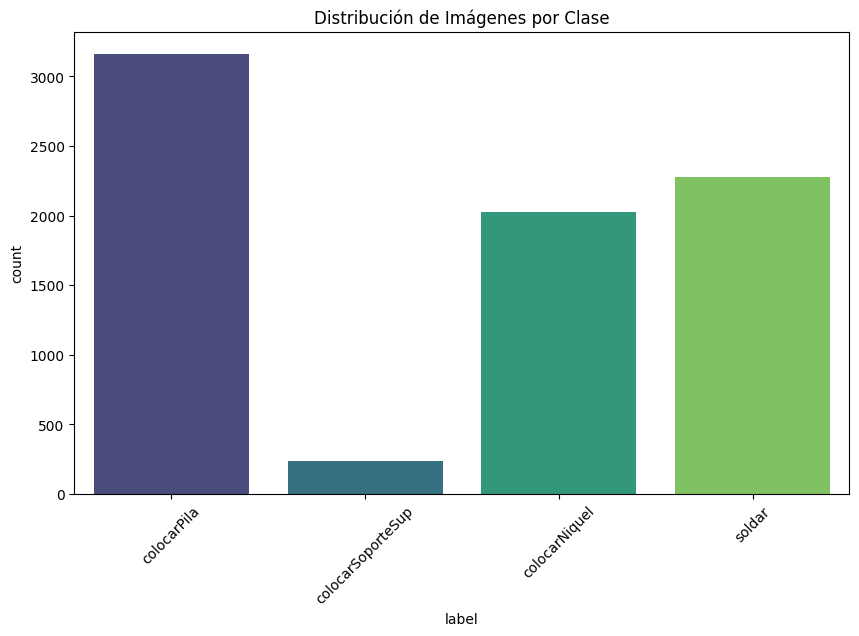

In [19]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribución de Imágenes por Clase')
plt.xticks(rotation=45)
plt.show()

In [20]:
resultados_tiempo = {}

## SOtA models

### ResNet50

Data augmentation se aplica solo en train porque test y val tienen que representar la realidad

In [21]:
# Crear dataset de entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(len(train_paths)) # Shuffle de rutas
            .map(lambda x, y: load_image_tf(x, y, method="resnet"), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            .map(augment_if_minority, num_parallel_calls=tf.data.AUTOTUNE) # Aumentar clase minoritaria
            .batch(32)
            .prefetch(tf.data.AUTOTUNE))

# Crear dataset de validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
          .map(lambda x, y: load_image_tf(x, y, method="resnet"), num_parallel_calls=tf.data.AUTOTUNE)
          .batch(32)
          .prefetch(tf.data.AUTOTUNE))

# Crear dataset de test
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = (test_ds
           .map(lambda x, y: load_image_tf(x, y, method="resnet"), num_parallel_calls=tf.data.AUTOTUNE)
           .batch(32)
           .prefetch(tf.data.AUTOTUNE))

In [25]:
base_resnet50_db = ResNet50(
    weights = None,
    include_top = False, # whether to include the fully-connected layer at the top of the network.
    input_shape = (256, 256, 3),  # if include_top true input shape must be (224, 224, 3) 
    pooling = "avg"
)

model_resnet50_db = Sequential([
    base_resnet50_db,
    layers.Dense(4, activation='softmax')   # 4 clases
])

epochs = 10

test_acc_resnet50_db, train_acc_resnet50_db, train_loss_resnet50_db, test_loss_resnet50_db, history_resnet50_db = training_pipeline_db(model_resnet50_db, train_ds, val_ds, test_ds, epochs=epochs)
print(f"Test accuracy: {test_acc_resnet50_db}\nTrain accuracy: {train_acc_resnet50_db}")
print(f"Test loss: {test_loss_resnet50_db}\nTrain loss: {train_loss_resnet50_db}")

Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1496s 10s/step - accuracy: 0.5874 - loss: 1.1777 - val_accuracy: 0.5731 - val_loss: 16.7521 - learning_rate: 0.0050
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1380s 9s/step - accuracy: 0.8104 - loss: 0.4627 - val_accuracy: 0.0308 - val_loss: 74.5208 - learning_rate: 0.0050
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1363s 9s/step - accuracy: 0.8689 - loss: 0.3297 - val_accuracy: 0.4505 - val_loss: 2.0596 - learning_rate: 0.0050
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1584s 10s/step - accuracy: 0.9267 - loss: 0.2138 - val_accuracy: 0.0308 - val_loss: 191.1614 - learning_rate: 0.0050
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 1606s 10s/step - accuracy: 0.8876 - loss: 0.3340 - val_accuracy: 0.0341 - val_loss: 70.1581 - learning_rate: 0.0050
Epoch 6/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9147 - loss: 0.2168
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
154/154 ━━━━━━━━━━━━━━━━━━━━ 1563s 10s/step - accuracy: 0.90

218 minutos

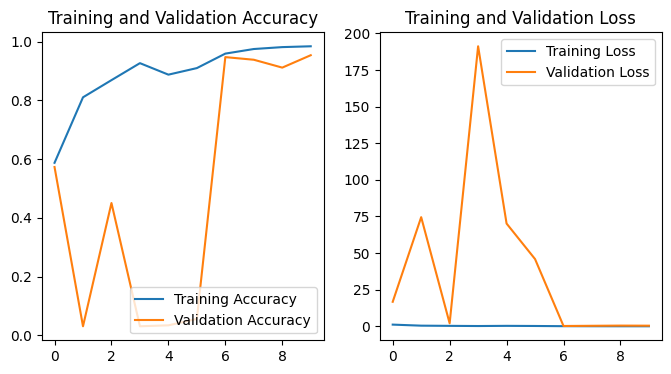

In [26]:
plot_from_history(history_resnet50_db, epochs = epochs)

In [27]:
model_resnet50_db.save("modelo_resnet50_db.keras")
save_history(history_resnet50_db, "history_resnet50_db.pkl")

In [22]:
model_resnet50_db = load_model("modelo_resnet50_db.keras")
history_resnet50_db = load_history("history_resnet50_db.pkl")

Historial cargado desde history_resnet50_db.pkl.


In [23]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_resnet50_db = model_resnet50_db.predict(test_ds)
y_pred_classes_resnet50_db = y_pred_resnet50_db.argmax(axis=1)
class_names = encoder.classes_ 

f1_resnet50_db = f1_score(y_true, y_pred_classes_resnet50_db, average="weighted")
print(f"F1 Score ResNet50 db: {f1_resnet50_db}")
print("-------------------------------------")

print("Classification Report ResNet50 db + no weights:")
print(classification_report(y_true, y_pred_classes_resnet50_db, target_names=class_names))

49/49 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step
F1 Score ResNet50 db: 0.9341710481879554
-------------------------------------
Classification Report ResNet50 db + no weights:
                   precision    recall  f1-score   support

    colocarNiquel       0.88      0.95      0.91       405
      colocarPila       0.99      1.00      1.00       632
colocarSoporteSup       0.00      0.00      0.00        48
           soldar       0.95      0.98      0.97       455

         accuracy                           0.95      1540
        macro avg       0.71      0.73      0.72      1540
     weighted avg       0.92      0.95      0.93      1540



c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [ ]:
cm_img = multilabel_confusion_matrix(y_true, y_pred_classes_resnet50_db)

print("=== MATRICES DE CONFUSIÓN POR CLASE ===")
print(f"{'Clase':<20} | {'TN':<5} | {'FP':<5} | {'FN':<5} | {'TP':<5} | {'Estado':<15}")
print("-" * 75)

for i, matrix in enumerate(cm_img):
    # Desglose de la matriz
    tn = matrix[0, 0]
    fp = matrix[0, 1]
    fn = matrix[1, 0]
    tp = matrix[1, 1]
    
    # Total de imágenes reales de esta clase
    total_clase = tp + fn
    
    umbral_alerta = total_clase * 0.25
    
    nombre_clase = class_names[i]
    
    print(f"{nombre_clase:<20} | {tn:<5.0f} | {fp:<5.0f} | {fn:<5.0f} | {tp:<5.0f} |", end="")
    
    # Lógica de estados personalizada
    if fp == 0 and fn == 0:
        print("✅")
    elif fp > umbral_alerta or fn > umbral_alerta:
        # Alerta si FP o FN superan el 25% de la presencia real de la clase
        print(f"⚠️ >25%")
    else:
        print("OK")

print("-" * 75)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1082  | 53    | 20    | 385   | Estable OK
colocarPila          | 903   | 5     | 1     | 631   | Estable OK
colocarSoporteSup    | 1492  | 0     | 48    | 0     | Revisar ⚠️ (>25%)
soldar               | 1064  | 21    | 10    | 445   | Estable OK
---------------------------------------------------------------------------


In [ ]:
y_true_soporteSup = [i for i, val in enumerate(y_true) if val == 2]

print(f"Cantidad de imágenes reales de colocarSoporteSup: {len(y_true_soporteSup)}\n")

for idx in y_true_soporteSup:
    ruta = test_paths[idx]
    real = class_names[y_true[idx]]
    pred = class_names[y_pred_classes_resnet50_db[idx]]
    
    print(f"Ruta: {ruta}")
    print(f"   - Real: {real} | Predicha: {pred}")
    print("-" * 30)

Cantidad de imágenes reales de colocarSoporteSup: 48

Ruta: ../capturas/capturas_256x256/capturasVR\Session_016/capture_0351.png
   - Real: colocarSoporteSup | Predicha: colocarNiquel
------------------------------
Ruta: ../capturas/capturas_256x256/capturasVR\Session_005/capture_0143.png
   - Real: colocarSoporteSup | Predicha: colocarPila
------------------------------
Ruta: ../capturas/capturas_256x256/capturasVR\Session_011/capture_0260.png
   - Real: colocarSoporteSup | Predicha: colocarNiquel
------------------------------
Ruta: ../capturas/capturas_256x256/capturasVR\Session_017/capture_0320.png
   - Real: colocarSoporteSup | Predicha: colocarNiquel
------------------------------
Ruta: ../capturas/capturas_256x256/capturasVR\Session_004/capture_0106.png
   - Real: colocarSoporteSup | Predicha: colocarNiquel
------------------------------
Ruta: ../capturas/capturas_256x256/capturasVR\Session_002/capture_0124.png
   - Real: colocarSoporteSup | Predicha: colocarPila
---------------

### EfficientNetB0 - Tensorflow

In [31]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [41]:
# Crear dataset de entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(len(train_paths)) # Shuffle de rutas
            .map(lambda x, y: load_image_tf(x, y, method="efficientnet"), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            .map(augment_if_minority, num_parallel_calls=tf.data.AUTOTUNE) # Aumentar clase minoritaria
            .batch(32)
            .prefetch(tf.data.AUTOTUNE))

# Crear dataset de validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
          .map(lambda x, y: load_image_tf(x, y, method="efficientnet"), num_parallel_calls=tf.data.AUTOTUNE)
          .batch(32)
          .prefetch(tf.data.AUTOTUNE))

# Crear dataset de test
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = (test_ds
           .map(lambda x, y: load_image_tf(x, y, method="efficientnet"), num_parallel_calls=tf.data.AUTOTUNE)
           .batch(32)
           .prefetch(tf.data.AUTOTUNE))

In [42]:
start_time = time.time()

base_efficientNetB0 = EfficientNetB0(
    include_top = False,
    weights = "imagenet",
    input_shape = (256, 256, 3),
    pooling = "avg"
)

model_efficientNetB0 = Sequential([
    base_efficientNetB0,
    layers.Dense(4, activation='softmax')   # 4 clases
])

epochs = 10


test_acc_efficientNetB0, train_acc_efficientNetB0, train_loss_efficientNetB0, test_loss_efficientNetB0, history_efficientNetB0 = training_pipeline_db(model_efficientNetB0, train_ds, val_ds, test_ds, epochs=epochs)
print(f"Test accuracy: {test_acc_efficientNetB0}\nTrain accuracy: {train_acc_efficientNetB0}")
print(f"Test loss: {test_loss_efficientNetB0}\nTrain loss: {train_loss_efficientNetB0}")

end_time = time.time()
training_time = end_time - start_time
resultados_tiempo['EfficientNetB0'] = training_time
print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time / 60:.2f} minutos")

Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 878s 6s/step - accuracy: 0.8914 - loss: 0.3404 - val_accuracy: 0.2622 - val_loss: 35.6072 - learning_rate: 0.0050
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 903s 6s/step - accuracy: 0.9373 - loss: 0.2254 - val_accuracy: 0.2662 - val_loss: 71.3745 - learning_rate: 0.0050
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 867s 6s/step - accuracy: 0.9685 - loss: 0.0941 - val_accuracy: 0.8369 - val_loss: 1.0562 - learning_rate: 0.0050
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 843s 5s/step - accuracy: 0.9799 - loss: 0.0704 - val_accuracy: 0.7086 - val_loss: 2.0053 - learning_rate: 0.0050
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 837s 5s/step - accuracy: 0.9823 - loss: 0.0576 - val_accuracy: 0.9383 - val_loss: 0.4473 - learning_rate: 0.0050
Epoch 6/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 836s 5s/step - accuracy: 0.9821 - loss: 0.0539 - val_accuracy: 0.9554 - val_loss: 0.3352 - learning_rate: 0.0050
Epoch 7/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 949s 6s/step - accuracy: 0.9882 - loss: 

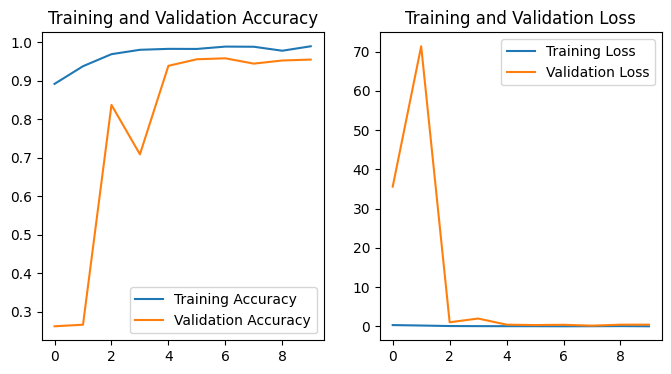

In [43]:
plot_from_history(history_efficientNetB0, epochs = epochs)

##### Save model

In [44]:
model_efficientNetB0.save("modelo_efficientNetB0.keras")
save_history(history_efficientNetB0, "history_efficientNetB0.pkl")

##### Load model

In [ ]:
model_efficientNetB0 = load_model("modelo_efficientNetB0.keras")
history_efficientNetB0 = load_history("history_efficientNetB0.pkl")

Historial cargado desde history_efficientNetB0.pkl.


#### Test

In [45]:
y_pred_efficientNetB0 = model_efficientNetB0.predict(test_ds)

y_pred_classes_efficientNetB0 = y_pred_efficientNetB0.argmax(axis=1)

f1_efficientNetB0 = f1_score(y_true, y_pred_classes_efficientNetB0, average="weighted")
print(f"F1 Score EfficientNetB0: {f1_efficientNetB0}")
print("-------------------------------------")

print("Classification Report EfficientNetB0:")
print(classification_report(y_true, y_pred_classes_efficientNetB0, target_names=class_names))

49/49 ━━━━━━━━━━━━━━━━━━━━ 39s 767ms/step
F1 Score EfficientNetB0: 0.9408832034416674
-------------------------------------
Classification Report EfficientNetB0:
                   precision    recall  f1-score   support

    colocarNiquel       0.87      1.00      0.93       405
      colocarPila       0.99      1.00      0.99       632
colocarSoporteSup       0.00      0.00      0.00        48
           soldar       1.00      0.96      0.98       455

         accuracy                           0.96      1540
        macro avg       0.71      0.74      0.73      1540
     weighted avg       0.93      0.96      0.94      1540



c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [46]:
cm_img = multilabel_confusion_matrix(y_true, y_pred_classes_efficientNetB0)

print("=== MATRICES DE CONFUSIÓN POR CLASE ===")
print(f"{'Clase':<20} | {'TN':<5} | {'FP':<5} | {'FN':<5} | {'TP':<5} | {'Estado':<15}")
print("-" * 75)

for i, matrix in enumerate(cm_img):
    # Desglose de la matriz
    tn = matrix[0, 0]
    fp = matrix[0, 1]
    fn = matrix[1, 0]
    tp = matrix[1, 1]
    
    # Total de imágenes reales de esta clase
    total_clase = tp + fn
    
    umbral_alerta = total_clase * 0.25
    
    nombre_clase = class_names[i]
    
    print(f"{nombre_clase:<20} | {tn:<5.0f} | {fp:<5.0f} | {fn:<5.0f} | {tp:<5.0f} |", end="")
    
    # Lógica de estados personalizada
    if fp == 0 and fn == 0:
        print("✅")
    elif fp > umbral_alerta or fn > umbral_alerta:
        # Alerta si FP o FN superan el 25% de la presencia real de la clase
        print(f"⚠️ >25%")
    else:
        print("OK")

print("-" * 75)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1074  | 61    | 1     | 404   |OK
colocarPila          | 900   | 8     | 1     | 631   |OK
colocarSoporteSup    | 1492  | 0     | 48    | 0     |⚠️ >25%
soldar               | 1085  | 0     | 19    | 436   |OK
---------------------------------------------------------------------------


In [50]:
# 1. Obtenemos los índices (como ya hacías)
y_true_soporteSup = [i for i, val in enumerate(y_true) if val == 2]

print(f"Cantidad de imágenes reales de colocarSoporteSup: {len(y_true_soporteSup)}\n")

# 2. Iteramos usando el índice para acceder a test_paths
for idx in y_true_soporteSup:
    ruta = test_paths[idx]
    real = class_names[y_true[idx]]
    pred = class_names[y_pred_classes_efficientNetB0[idx]]
    
    print(f"Ruta: {ruta}")
    print(f"   - Real: {real} | Predicha: {pred}")
    print("-" * 30)

Cantidad de imágenes reales de colocarSoporteSup: 48

Ruta: ../capturas/capturas_256x256/capturasVR\Session_016/capture_0351.png
   - Real: colocarSoporteSup | Predicha: colocarNiquel
------------------------------
Ruta: ../capturas/capturas_256x256/capturasVR\Session_005/capture_0143.png
   - Real: colocarSoporteSup | Predicha: colocarPila
------------------------------
Ruta: ../capturas/capturas_256x256/capturasVR\Session_011/capture_0260.png
   - Real: colocarSoporteSup | Predicha: colocarNiquel
------------------------------
Ruta: ../capturas/capturas_256x256/capturasVR\Session_017/capture_0320.png
   - Real: colocarSoporteSup | Predicha: colocarNiquel
------------------------------
Ruta: ../capturas/capturas_256x256/capturasVR\Session_004/capture_0106.png
   - Real: colocarSoporteSup | Predicha: colocarNiquel
------------------------------
Ruta: ../capturas/capturas_256x256/capturasVR\Session_002/capture_0124.png
   - Real: colocarSoporteSup | Predicha: colocarPila
---------------

### EfficientNetB7 - tensorflow

In [34]:
from tensorflow.keras.applications import EfficientNetB7

In [ ]:
base_efficientNetB7 = EfficientNetB7(
    include_top = False,
    weights = "imagenet",
    input_shape = (256, 256, 3),
    pooling = "avg"
)

model_efficientNetB7 = Sequential([
    base_efficientNetB7,
    layers.Dense(4, activation='softmax')   # 4 clases
])

epochs = 10

test_acc_efficientNetB7, train_acc_efficientNetB7, history_efficientNetB7 = training_pipeline(model_efficientNetB7, X_train_tensor, train_labels_encoded, X_test_tensor, test_labels_encoded, epochs = epochs)
print(f"Test accuracy: {test_acc_efficientNetB7}\nTrain accuracy: {train_acc_efficientNetB7}")

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 7193s 164s/step - accuracy: 0.8635 - loss: 0.5226 - val_accuracy: 0.0296 - val_loss: 2579554.7500 - learning_rate: 0.0050
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 6271s 146s/step - accuracy: 0.9236 - loss: 0.2831 - val_accuracy: 0.1006 - val_loss: 1296.8748 - learning_rate: 0.0050
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 5915s 138s/step - accuracy: 0.9488 - loss: 0.1738 - val_accuracy: 0.4172 - val_loss: 5.7212 - learning_rate: 0.0050
Epoch 4/10
20/43 ━━━━━━━━━━━━━━━━━━━━ 51:09 133s/step - accuracy: 0.9333 - loss: 0.2174

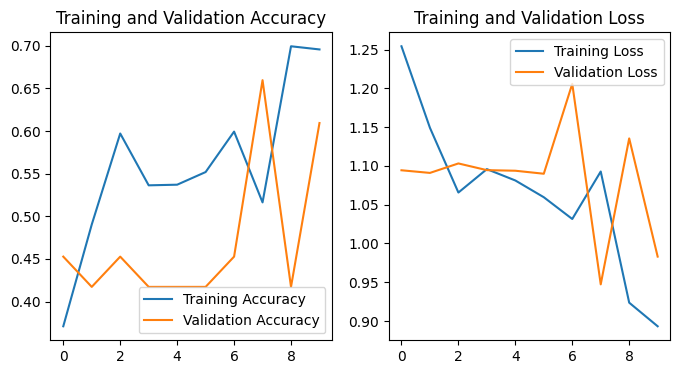

In [ ]:
plot_from_history(history_efficientNetB7, epochs = epochs)

##### Save model

In [ ]:
model_efficientNetB7.save("modelo_clas_proc_efficientNetB7.keras")
save_history(history_efficientNetB7, "history_efficientNetB7.pkl")

##### Load model

In [ ]:
model_efficientNetB7 = load_model("modelo_clas_proc_efficientNetB7.keras")
history_efficientNetB7 = load_history("history_efficientNetB7.pkl")

Historial cargado desde history_resnet50_imgnet.pkl.


#### Test

In [ ]:
y_pred_efficientNetB7 = model_efficientNetB7.predict(test_images)

y_pred_classes_efficientNetB7 = y_pred_efficientNetB7.argmax(axis=1)

f1_efficientNetB7 = f1_score(test_labels_encoded, y_pred_classes_efficientNetB7, average="weighted")
print(f"F1 Score EfficientNetB7: {f1_efficientNetB7}")
print("-------------------------------------")

cm_img = multilabel_confusion_matrix(test_labels_encoded, y_pred_classes_efficientNetB7)
print("Confusion Matrix EfficientNetB7:")
for i, matrix in enumerate(cm_img):
    print(f"Clase {i}: Pred + || Pred -  \n True + {matrix}\n")
print("-------------------------------------")

print("Classification Report EfficientNetB7:")
print(classification_report(test_labels_encoded, y_pred_classes_efficientNetB7, target_names=["colocarPila", "colocarSoporteSup", "colocarNiquel", "soldar"]))

14/14 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step 
F1 Score EfficientNetB0: 0.5315761592064201
-------------------------------------
Confusion Matrix EfficientNetB0:
Clase 0: Pred + || Pred -  
 True + [[111 145]
 [ 20 146]]

Clase 1: Pred + || Pred -  
 True + [[409   0]
 [ 13   0]]

Clase 2: Pred + || Pred -  
 True + [[364   0]
 [ 58   0]]

Clase 3: Pred + || Pred -  
 True + [[207  30]
 [ 84 101]]

-------------------------------------
Classification Report EfficientNetB0:
                   precision    recall  f1-score   support

      colocarPila       0.50      0.88      0.64       166
colocarSoporteSup       0.00      0.00      0.00        13
    colocarNiquel       0.00      0.00      0.00        58
           soldar       0.77      0.55      0.64       185

         accuracy                           0.59       422
        macro avg       0.32      0.36      0.32       422
     weighted avg       0.54      0.59      0.53       422



C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas

### MobileNet

In [35]:
from tensorflow.keras.applications import MobileNet

In [36]:
# Crear dataset de entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(len(train_paths)) # Shuffle de rutas
            .map(lambda x, y: load_image_tf(x, y, method="mobilenet"), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            .map(augment_if_minority, num_parallel_calls=tf.data.AUTOTUNE) # Aumentar clase minoritaria
            .batch(32)
            .prefetch(tf.data.AUTOTUNE))

# Crear dataset de validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
          .map(lambda x, y: load_image_tf(x, y, method="mobilenet"), num_parallel_calls=tf.data.AUTOTUNE)
          .batch(32)
          .prefetch(tf.data.AUTOTUNE))

# Crear dataset de test
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = (test_ds
           .map(lambda x, y: load_image_tf(x, y, method="mobilenet"), num_parallel_calls=tf.data.AUTOTUNE)
           .batch(32)
           .prefetch(tf.data.AUTOTUNE))

In [38]:
start_time = time.time()

base_mobilenet = MobileNet(
    include_top = False,
    weights = None,
    input_shape = (256, 256, 3),
    pooling = "avg"
)

model_mobilenet = Sequential([
    base_mobilenet,
    layers.Dense(4, activation='softmax')   # 4 clases
])

epochs = 10

test_acc_mobilenet, train_acc_mobilenet, train_loss_mobilenet, test_loss_mobilenet, history_mobilenet = training_pipeline_db(model_mobilenet, train_ds, val_ds, test_ds, epochs=epochs)
print(f"Test accuracy: {test_acc_mobilenet}\nTrain accuracy: {train_acc_mobilenet}")
print(f"Test loss: {test_loss_mobilenet}\nTrain loss: {train_loss_mobilenet}")

end_time = time.time()
training_time = end_time - start_time
resultados_tiempo['MobileNet'] = training_time
print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time / 60:.2f} minutos")

Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 465s 3s/step - accuracy: 0.9113 - loss: 0.2355 - val_accuracy: 0.2630 - val_loss: 2.8328 - learning_rate: 0.0050
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 450s 3s/step - accuracy: 0.9732 - loss: 0.0760 - val_accuracy: 0.2630 - val_loss: 4.0969 - learning_rate: 0.0050
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 450s 3s/step - accuracy: 0.9842 - loss: 0.0480 - val_accuracy: 0.0308 - val_loss: 6.5453 - learning_rate: 0.0050
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9669 - loss: 0.1051
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
154/154 ━━━━━━━━━━━━━━━━━━━━ 449s 3s/step - accuracy: 0.9493 - loss: 0.1515 - val_accuracy: 0.4107 - val_loss: 58.9881 - learning_rate: 0.0050
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 450s 3s/step - accuracy: 0.9830 - loss: 0.0535 - val_accuracy: 0.5909 - val_loss: 1.5913 - learning_rate: 0.0025
Epoch 6/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 452s 3s/step - accuracy: 0.9882 - loss: 0.03

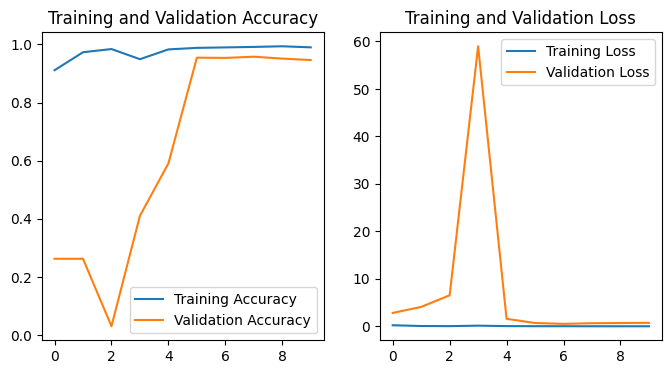

In [39]:
plot_from_history(history_mobilenet, epochs = epochs)

In [40]:
model_mobilenet.save("model_mobilenet.keras")
save_history(history_mobilenet, "history_mobilenet.pkl")

In [37]:
model_mobilenet = load_model("model_mobilenet.keras")
history_mobilenet = load_history("history_mobilenet.pkl")

Historial cargado desde history_mobilenet.pkl.


In [38]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_mobilenet = model_mobilenet.predict(test_ds)
y_pred_classes_mobilenet = y_pred_mobilenet.argmax(axis=1)
class_names = encoder.classes_ 

f1_mobilenet = f1_score(y_true, y_pred_classes_mobilenet, average="weighted")
print(f"F1 Score MobileNet: {f1_mobilenet}")
print("-------------------------------------")

print("Classification Report MobileNet:")
print(classification_report(y_true, y_pred_classes_mobilenet, target_names=class_names))

49/49 ━━━━━━━━━━━━━━━━━━━━ 29s 577ms/step
F1 Score MobileNet: 0.9292388083093832
-------------------------------------
Classification Report MobileNet:
                   precision    recall  f1-score   support

    colocarNiquel       0.86      0.96      0.91       405
      colocarPila       0.98      1.00      0.99       632
colocarSoporteSup       0.00      0.00      0.00        48
           soldar       0.97      0.95      0.96       455

         accuracy                           0.94      1540
        macro avg       0.70      0.73      0.72      1540
     weighted avg       0.92      0.94      0.93      1540



c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [ ]:
cm_img = multilabel_confusion_matrix(y_true, y_pred_classes_mobilenet)

print("=== MATRICES DE CONFUSIÓN POR CLASE ===")
print(f"{'Clase':<20} | {'TN':<5} | {'FP':<5} | {'FN':<5} | {'TP':<5} | {'Estado':<15}")
print("-" * 75)

for i, matrix in enumerate(cm_img):
    # Desglose de la matriz
    tn = matrix[0, 0]
    fp = matrix[0, 1]
    fn = matrix[1, 0]
    tp = matrix[1, 1]
    
    # Total de imágenes reales de esta clase
    total_clase = tp + fn
    
    umbral_alerta = total_clase * 0.25
    
    nombre_clase = class_names[i]
    
    print(f"{nombre_clase:<20} | {tn:<5.0f} | {fp:<5.0f} | {fn:<5.0f} | {tp:<5.0f} |", end="")
    
    # Lógica de estados personalizada
    if fp == 0 and fn == 0:
        print("✅")
    elif fp > umbral_alerta or fn > umbral_alerta:
        # Alerta si FP o FN superan el 25% de la presencia real de la clase
        print(f"⚠️ >25%")
    else:
        print("OK")

print("-" * 75)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1073  | 62    | 15    | 390   | Estable OK
colocarPila          | 898   | 10    | 3     | 629   | Estable OK
colocarSoporteSup    | 1492  | 0     | 48    | 0     | Revisar ⚠️ (>25%)
soldar               | 1070  | 15    | 21    | 434   | Estable OK
---------------------------------------------------------------------------


In [49]:
y_true_soporteSup = [i for i, val in enumerate(y_true) if val == 2]

print(f"Cantidad de imágenes reales de colocarSoporteSup: {len(y_true_soporteSup)}\n")

for idx in y_true_soporteSup:
    ruta = test_paths[idx]
    real = class_names[y_true[idx]]
    pred = class_names[y_pred_classes_mobilenet[idx]]
    
    print(f"Ruta: {ruta}")
    print(f"   - Real: {real} | Predicha: {pred}")
    print("-" * 30)

Cantidad de imágenes reales de colocarSoporteSup: 48

Ruta: ../capturas/capturas_256x256/capturasVR\Session_016/capture_0351.png
   - Real: colocarSoporteSup | Predicha: colocarNiquel
------------------------------
Ruta: ../capturas/capturas_256x256/capturasVR\Session_005/capture_0143.png
   - Real: colocarSoporteSup | Predicha: colocarPila
------------------------------
Ruta: ../capturas/capturas_256x256/capturasVR\Session_011/capture_0260.png
   - Real: colocarSoporteSup | Predicha: colocarNiquel
------------------------------
Ruta: ../capturas/capturas_256x256/capturasVR\Session_017/capture_0320.png
   - Real: colocarSoporteSup | Predicha: colocarNiquel
------------------------------
Ruta: ../capturas/capturas_256x256/capturasVR\Session_004/capture_0106.png
   - Real: colocarSoporteSup | Predicha: colocarNiquel
------------------------------
Ruta: ../capturas/capturas_256x256/capturasVR\Session_002/capture_0124.png
   - Real: colocarSoporteSup | Predicha: colocarPila
---------------

### Resultados 17 sesiones con data augmentation

| Modelo | Acc train | Acc test | Tiempo|
|----------|----------|----------|----------|
| ResNet   |          |          |          | 
| EfficientNetB0 |    |          |          |
| MobileNet   |       |          |          |
